
# Lab02: Compressed DenseNet for Crowd Counting

> Dataset structure:
> ```
> <DATA_ROOT>/
> ├── Lab02_CDenseNet.ipynb
> ├── CDenseNet.py
> └── data/
>     ├── video/vidf/vidf1_33_ZZZ.y/*.png  # e.g., vidf1_33_ZZZ_fFFF.png ...
>     └── gt/vidf/*.mat    # e.g., vidf1_33_ZZZ_count_2K_roi*.mat ...
> ```

## 0. Mount Google Drive

In [1]:
# from google.colab import drive

# Mount Google Drive
# drive.mount('/content/drive')
# You need to modify this part to the directory where your code is located, i.e., <DATA_ROOT>
# %cd "/content/drive/MyDrive/Lab02/"

## 1. Import Libraries

In [2]:
%pip install torchinfo


Note: you may need to restart the kernel to use updated packages.


In [3]:
# ---- import library ----
import os, re, glob, random
from typing import List, Tuple, Dict
import numpy as np
from PIL import Image
from scipy.io import loadmat

import torch
torch.cuda.is_available()

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

from torchvision import transforms, utils as vutils
import matplotlib.pyplot as plt

%matplotlib inline

def set_global_seed(seed: int):
  # Python
  random.seed(seed)
  # NumPy
  np.random.seed(seed)
  # PyTorch
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

  print(f"[INFO] Global seed set to {seed}")

set_global_seed(37)

[INFO] Global seed set to 37


## 2. Dataset Definition

In [4]:
# File naming for vidf frames: vidf1_33_ZZZ_fFFF.png (ZZZ: 000..019, FFF: 001..200)
FNAME_RE = re.compile(r"vidf1_33_(\d{3})_f(\d{3})\.png")

# Train: 401..2900 | Val: 2901..3600 | Test: 1..400 & 3601..4000
SPLIT_RANGES = {
  "train": [(401, 2900)],
  "val":   [(2901, 3600)],
  # "test":  [(1, 400), (3601, 4000)],   # full test set
  "test":  [(3601, 3800)],             # public test set
}

In [5]:
class UCSDDataset(Dataset):
  """
  UCSD vidf frames -> (x, people_cnts) where x is grayscale image tensor, people_cnts is [r, l, t] crowd counts for the frame.
  """
  def __init__(self, split: str = "train", transform=None):
    super().__init__()
    assert split in ["train", "val", "test"]
    self.img_dir = './data/video/vidf'
    self.gt_dir  = './data/gt/vidf'

    # preprocess transform: to tensor + normalize to [-1,1]
    self.transform = transform or transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    # enumerate frames that belong to this split
    self.items: List[Tuple[int, int, str]] = []  # (clip_idx, f_in_clip, path)
    pngs = sorted(glob.glob(os.path.join(self.img_dir, "**", "*.png"), recursive=True))
    for p in pngs:
      m = FNAME_RE.match(os.path.basename(p))
      if not m:
        continue
      clip_str, f_str = m.groups()
      clip_idx = int(clip_str)           # 000..019
      f_in_clip = int(f_str)             # 001..200
      gidx = clip_idx * 200 + f_in_clip  # global indexing
      for a, b in SPLIT_RANGES[split]:
        if a <= gidx <= b:
          self.items.append((clip_idx, f_in_clip, p))
          break

    # cache for per-clip count .mat files
    self._count_cache: Dict[int, Dict[str, np.ndarray]] = {}

  def __len__(self):
    return len(self.items)

  def __getitem__(self, idx):
    clip_idx, f_in_clip, img_p = self.items[idx]
    img = Image.open(img_p).convert('L')
    x = self.transform(img)
    dmap = self._load_counts_clip(clip_idx)
    k = f_in_clip - 1  # 0-based index into 200 frames
    r = dmap.get('r', None)
    l = dmap.get('l', None)
    t = dmap.get('t', None)
    if r is None or l is None or t is None:
      raise KeyError(f"[ERROR] Missing 'r','l','t' in dirs for clip {clip_idx}. Have={list(dmap.keys())}")
    people_cnts = torch.tensor([r[k], l[k], t[k]], dtype=torch.float32)
    return x, people_cnts

  def _load_counts_clip(self, clip_idx: int) -> Dict[str, np.ndarray]:
    """
      Loader for DT mat layout:
       - file:  vidf1_33_ZZZ_count_2K_roi_mainwalkway.mat
       - key:   'cgt' (1x1 struct)
       - fields: cgt.dir (['r','l','t','n']), cgt.count (cell of 4 vectors length 200)
      Returns dict {'r': vec, 'l': vec, 't': vec} as float32.
    """
    if clip_idx in self._count_cache:
      return self._count_cache[clip_idx]

    path = os.path.join(self.gt_dir, f"vidf1_33_{clip_idx:03d}_count_2K_roi_mainwalkway.mat")
    mat = loadmat(path, squeeze_me=False, struct_as_record=False)

    # 1x1 MATLAB struct at key 'cgt'
    entry = mat['cgt'].flat[0]  # get the single struct

    # Access fields
    dirs_raw   = getattr(entry, 'dir')
    counts_raw = getattr(entry, 'count')

    # Normalize to plain Python lists
    dirs_seq   = np.squeeze(dirs_raw).ravel()
    counts_seq = np.squeeze(counts_raw).ravel()

    # Convert names to strings and counts to float arrays
    dirs_list   = [str(np.squeeze(d).item()) for d in dirs_seq]
    counts_list = [np.squeeze(c).astype(np.float32) for c in counts_seq]  # (200,) each

    # Build the map; ignore 'n' (no motion)
    dmap = {}
    for name, vec in zip(dirs_list, counts_list):
      k = name.strip().lower()
      if   k == 'r': dmap['r'] = vec
      elif k == 'l': dmap['l'] = vec
      elif k == 't': dmap['t'] = vec

    missing = [nm for nm in ('r','l','t') if nm not in dmap]
    if missing:
      raise KeyError(f"[ERROR] Missing {missing} in GT for clip {clip_idx}. dirs={dirs_list}")

    # Cache & return
    self._count_cache[clip_idx] = dmap
    return dmap

## 3. Visualize Sample Frames & Labels

Labels [r, l, t] for shown samples:
  #00 -> [8.0, 9.0, 17.0]
  #01 -> [5.0, 8.0, 13.0]
  #02 -> [10.0, 13.0, 23.0]
  #03 -> [8.0, 13.0, 21.0]


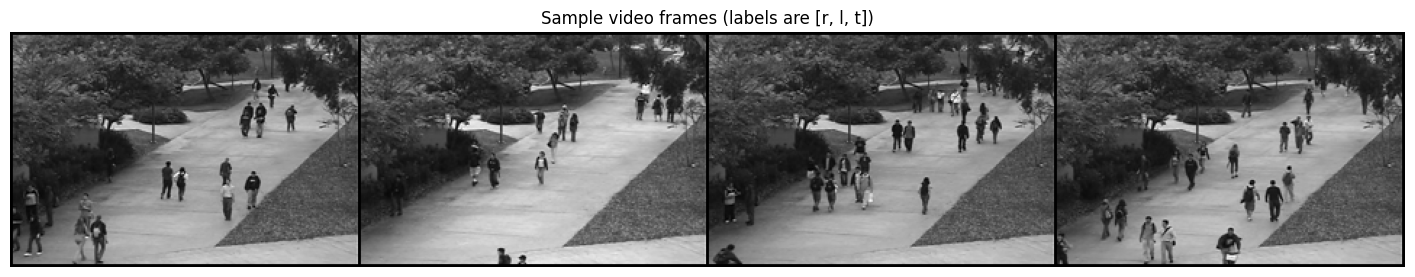

In [6]:
def visualize_samples(dataset: UCSDDataset, n: int = 4):
  """Show a grid of n sample images and print their [r,l,t] labels."""
  if len(dataset) == 0:
    print("[WARN] Dataset is empty. Please check DATA_ROOT.")
    return

  idxs = [random.randrange(len(dataset)) for _ in range(min(n, len(dataset)))]
  xs, ys = [], []
  for idx in idxs:
    x, people_cnts = dataset[idx]
    xs.append(x)
    ys.append(people_cnts.numpy())

  cols = min(8, len(xs))
  rows = int(np.ceil(len(xs) / cols))
  grid = vutils.make_grid(xs, nrow=cols, normalize=True, scale_each=True)

  plt.figure(figsize=(4.5*cols, 3.8*rows))  # Same scaling as lower function
  plt.axis('off')
  plt.title("Sample video frames (labels are [r, l, t])")
  plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap='gray')

  print("Labels [r, l, t] for shown samples:")
  for i, people_cnts in enumerate(ys):
    print(f"  #{i:02d} -> {[float(f'{v:.2f}') for v in people_cnts.tolist()]}")

try:
  _tmp_ds = UCSDDataset(split="train")
  visualize_samples(_tmp_ds, n=4)
except Exception as e:
  print("[WARN] Visualization skipped:", e)

## 4. Import Model

In [7]:
from CDenseNet import LDB, CDenseNet

model = CDenseNet()

In [8]:
model_summary = summary(model,
                       input_size=(1, 1, 158, 238),
                       device='cuda',
                       depth=9999,  # Large int value to show full depth
                       col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"],
                       row_settings=["var_names"])

print(model_summary)

with open('summary.txt', 'w') as f:
  f.write(str(model_summary))

print("[INFO] Summary displayed above and saved to summary.txt")

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
CDenseNet (CDenseNet)                    [1, 1, 158, 238]          [1, 3]                    --                        --                        --
├─Sequential (stem)                      [1, 1, 158, 238]          [1, 32, 158, 238]         --                        --                        --
│    └─Conv2d (0)                        [1, 1, 158, 238]          [1, 32, 158, 238]         288                       [3, 3]                    10,829,952
│    └─BatchNorm2d (1)                   [1, 32, 158, 238]         [1, 32, 158, 238]         64                        --                        64
│    └─ReLU (2)                          [1, 32, 158, 238]         [1, 32, 158, 238]         --                        --                        --
├─Sequential (blocks)                    [1, 32, 158, 238]         [1, 32, 158, 238]         --  

## 5. Create DataLoaders

In [9]:
batch_size = 8

# Create dataset instances
train_ds = UCSDDataset(split="train")
val_ds   = UCSDDataset(split="val")
test_ds  = UCSDDataset(split="test")

# Create data loaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

print(f"[INFO] Dataset sizes: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

[INFO] Dataset sizes: train=2500, val=700, test=200


## 6. Training Setup

In [10]:

class MAEMSELoss(nn.Module): 
    def __init__(self, alpha=0.5): 
        super().__init__() 
        self.mae = nn.L1Loss() 
        self.mse = nn.MSELoss() 
        self.alpha = alpha 
    def forward(self, pred, target): 
        return self.alpha * self.mae(pred, target) + (1 - self.alpha) * self.mse(pred, target)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

####################  implement your optimizer ###################################
## you can use any training methods if you want (ex:lr decay, weight decay.....)

# you can try 10~15 at first
num_epochs = 300
# Learning rate
lr = 5e-4

# Loss function
# criterion =  nn.MSELoss()
# criterion = nn.SmoothL1Loss(beta=1.0)  
criterion = MAEMSELoss(alpha=0.7) # 偏重 MAE

# Optimizer
#op AdamW sch CosineAnnealingLR 2.24
#op Adam sch StepLR 1.8535
#op AdamW sch StepLR 2.1454
#op Adam sch  CosineAnnealingLR 2.0695
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
# optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

# Learning rate scheduler (optional)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


[INFO] Using device: cuda


## 
7. Training Loop

In [11]:
from tqdm.auto import tqdm
import time
model = model.to(device)

ckpt_path = "model.pth"

# Early stopping
patience = 30   # 容忍多少 epoch 沒有進步
mae_best = float('inf')
no_improve = 0
best_epoch = 0

# 紀錄每個 epoch 的變化
history = {
    'train_loss': [],
    'val_loss': [],
    'mae': [],
    'rmse': []
}

total_start_time = time.time()
for epoch in range(1, num_epochs + 1):
    start_time = time.time()
    # ---------- Training phase ----------
    model.train()  # Set the model to training mode
    running_loss = 0.0
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} [Train]', leave=False, position=0, smoothing=0.1)
    for in_img, people_cnts in train_bar:
        in_img, people_cnts = in_img.to(device, non_blocking=True), people_cnts.to(device, non_blocking=True)
        
        #################################################
        # Please finish the "Training phase" code here.
        optimizer.zero_grad()               # reset gradient
        outputs = model(in_img)             # forward pass
        loss = criterion(outputs, people_cnts)  # compute loss
        loss.backward()                     # backpropagation
        optimizer.step()                    # update weights
        
        #################################################
        
        running_loss += loss.item() * people_cnts.size(0)
        train_bar.set_postfix(loss=f'{loss.item():.4f}')
    
    # ---------- Validation phase ----------
    model.eval()  # Set the model to evaluation mode
    val_loss = 0
    # Per-component MAE/RMSE accumulators for [r, l, t]
    abs_sum = torch.zeros(3, dtype=torch.float64)
    sqr_sum = torch.zeros(3, dtype=torch.float64)
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch}/{num_epochs} [Val]', leave=False, position=0, smoothing=0.1)
        for in_img, people_cnts in val_bar:
            in_img, people_cnts = in_img.to(device, non_blocking=True), people_cnts.to(device, non_blocking=True)
            
            ###################################################
            # Forward pass for validation
            # Please finish the "Validation phase" code here.
            outputs = model(in_img)                 # forward pass
            loss = criterion(outputs, people_cnts)  # compute loss
            
            ###################################################
            val_loss += loss.item() * people_cnts.size(0)
            # Calculate metrics for validation results
            err = outputs - people_cnts
            abs_sum += err.abs().sum(dim=0).double().cpu()
            sqr_sum += (err ** 2).sum(dim=0).double().cpu()
            val_bar.set_postfix(loss=f'{loss.item():.4f}')
    
    # ---------- Epoch summary ----------
    epoch_loss = running_loss / len(train_ds)
    avg_val_loss = val_loss / len(val_ds)
    mae = (abs_sum / len(val_ds)).tolist()
    avg_mae = sum(mae) / 3.0
    rmse = torch.sqrt(sqr_sum / len(val_ds)).tolist()
    avg_rmse = sum(rmse) / 3.0
    if scheduler:
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(avg_mae)  # 用 validation metric 來判斷
        else:
            scheduler.step()         # StepLR / CosineAnnealingLR
    
    if avg_mae < mae_best:
        mae_best = avg_mae
        no_improve = 0
        best_epoch = epoch
        print("model saved at Epoch ",best_epoch)
        torch.save(model.state_dict(), ckpt_path)
    else:
        no_improve += 1

    # 記錄每個 epoch 的結果
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(avg_val_loss)
    history['mae'].append(avg_mae)
    history['rmse'].append(avg_rmse)
    
    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch}, best Avg MAE={mae_best:.4f}")
        break
    
    end_time = time.time()
    print(f"[Epoch {epoch:2d}] "
        f"Train Loss: {epoch_loss:8.4f} | "
        f" MAE[r,l,t] = [{mae[0]:7.4f}, {mae[1]:7.4f}, {mae[2]:7.4f}] | "
        f"Avg  MAE: {avg_mae:7.4f} | Time: {end_time - start_time:.2f} sec")
    print(f"           "
        f"  Val Loss: {avg_val_loss:8.4f} | "
        f"RMSE[r,l,t] = [{rmse[0]:7.4f}, {rmse[1]:7.4f}, {rmse[2]:7.4f}] | "
        f"Avg RMSE: {avg_rmse:7.4f} | Current LR: {scheduler.get_last_lr()}")

/nashome/NVL4/msedalab/m314510196/.pyenv/versions/3.12.11/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
                                                                                                                                                                                                

model saved at Epoch  1
[Epoch  1] Train Loss:  45.9352 |  MAE[r,l,t] = [ 1.9535,  6.4929,  6.9717] | Avg  MAE:  5.1394 | Time: 70.82 sec
             Val Loss:  15.1208 | RMSE[r,l,t] = [ 2.2365,  7.2906,  7.5550] | Avg RMSE:  5.6940 | Current LR: [0.000499986292341378]


[Epoch  2] Train Loss:   7.3134 |  MAE[r,l,t] = [ 7.6489,  2.4464,  8.1308] | Avg  MAE:  6.0754 | Time: 70.21 sec
             Val Loss:  19.2746 | RMSE[r,l,t] = [ 8.1359,  3.0488,  8.6447] | Avg RMSE:  6.6098 | Current LR: [0.0004999451708687113]


[Epoch  3] Train Loss:   6.4210 |  MAE[r,l,t] = [ 2.7884,  5.8217,  8.7534] | Avg  MAE:  5.7878 | Time: 69.65 sec
             Val Loss:  17.9555 | RMSE[r,l,t] = [ 3.3695,  6.6639,  9.1257] | Avg RMSE:  6.3864 | Current LR: [0.0004998766400914329]


model saved at Epoch  4
[Epoch  4] Train Loss:   5.2261 |  MAE[r,l,t] = [ 2.3595,  3.1307,  2.1173] | Avg  MAE:  2.5358 | Time: 69.91 sec
             Val Loss:   4.7208 | RMSE[r,l,t] = [ 2.8371,  3.8170,  2.6149] | Avg RMSE:  3.0897 | Current LR: [0.0004997807075247146]


...

[Epoch 46] Train Loss:   0.7917 |  MAE[r,l,t] = [ 3.3912,  3.5968,  2.4642] | Avg  MAE:  3.1507 | Time: 266.46 sec
             Val Loss:   6.7500 | RMSE[r,l,t] = [ 4.2668,  4.3405,  2.8980] | Avg RMSE:  3.8351 | Current LR: [0.00047155089480780375]


[Epoch 47] Train Loss:   0.7867 |  MAE[r,l,t] = [ 2.3100,  4.1365,  3.2580] | Avg  MAE:  3.2348 | Time: 270.91 sec
             Val Loss:   6.9915 | RMSE[r,l,t] = [ 2.6597,  4.8852,  4.0412] | Avg RMSE:  3.8620 | Current LR: [0.0004703258630162481]


[Epoch 48] Train Loss:   0.7731 |  MAE[r,l,t] = [ 2.3410,  2.9868,  2.1711] | Avg  MAE:  2.4997 | Time: 270.39 sec
             Val Loss:   4.6234 | RMSE[r,l,t] = [ 2.8486,  3.7333,  2.5855] | Avg RMSE:  3.0558 | Current LR: [0.000469076670010966]


[Epoch 49] Train Loss:   0.7136 |  MAE[r,l,t] = [ 2.1655,  3.7724,  2.6595] | Avg  MAE:  2.8658 | Time: 265.62 sec
             Val Loss:   5.6551 | RMSE[r,l,t] = [ 2.5898,  4.4315,  3.1852] | Avg RMSE:  3.4022 | Current LR: [0.00046780345278004754]


Early stopping at epoch 50, best Avg MAE=2.3458


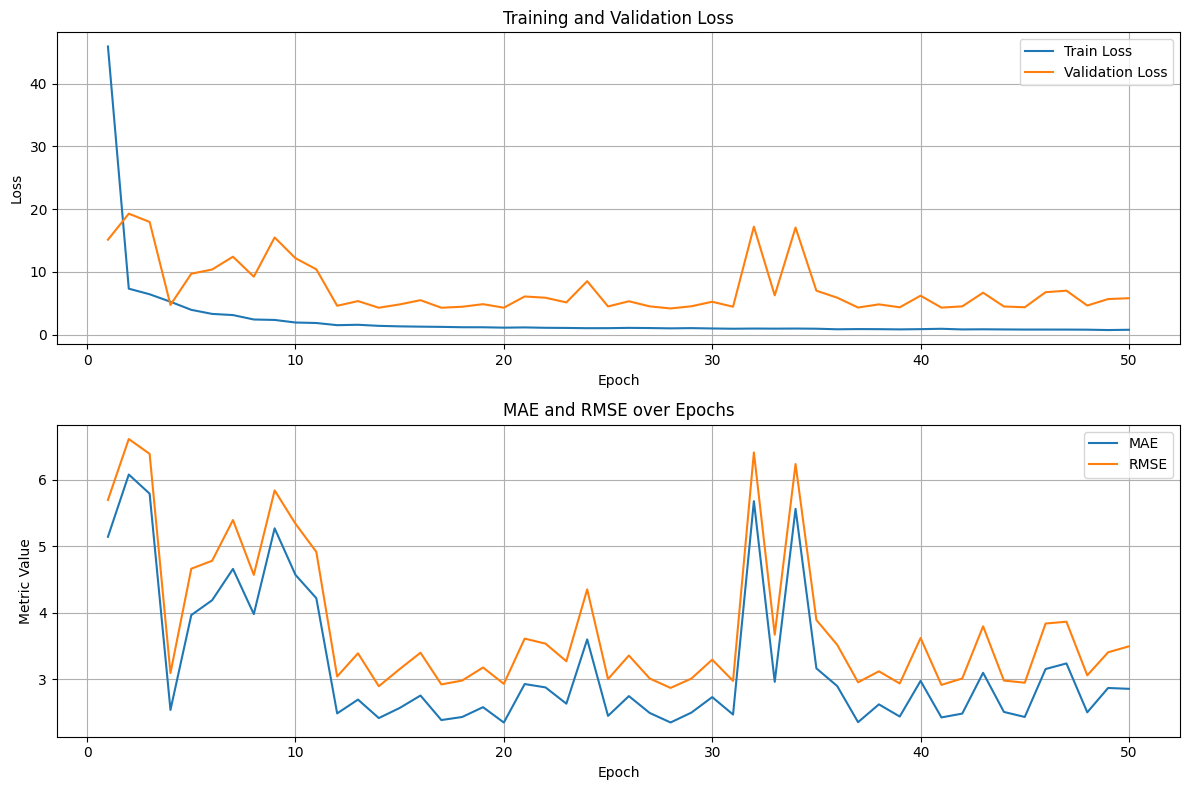

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 8))

# Loss 曲線
plt.subplot(2, 1, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# MAE / RMSE 曲線
plt.subplot(2, 1, 2)
plt.plot(epochs, history['mae'], label='MAE')
plt.plot(epochs, history['rmse'], label='RMSE')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('MAE and RMSE over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 8. Inference on Test Set

/tmp/ipykernel_3321969/789710535.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(_ckpt_path, map_location=device)


[INFO] Loaded model state dict from checkpoint: model.pth


[TEST]  MAE[r,l,t] = [1.1591, 2.3694, 1.5349] | Avg  MAE = 1.6878
[TEST] RMSE[r,l,t] = [1.5294, 2.6437, 1.8436] | Avg RMSE = 2.0056


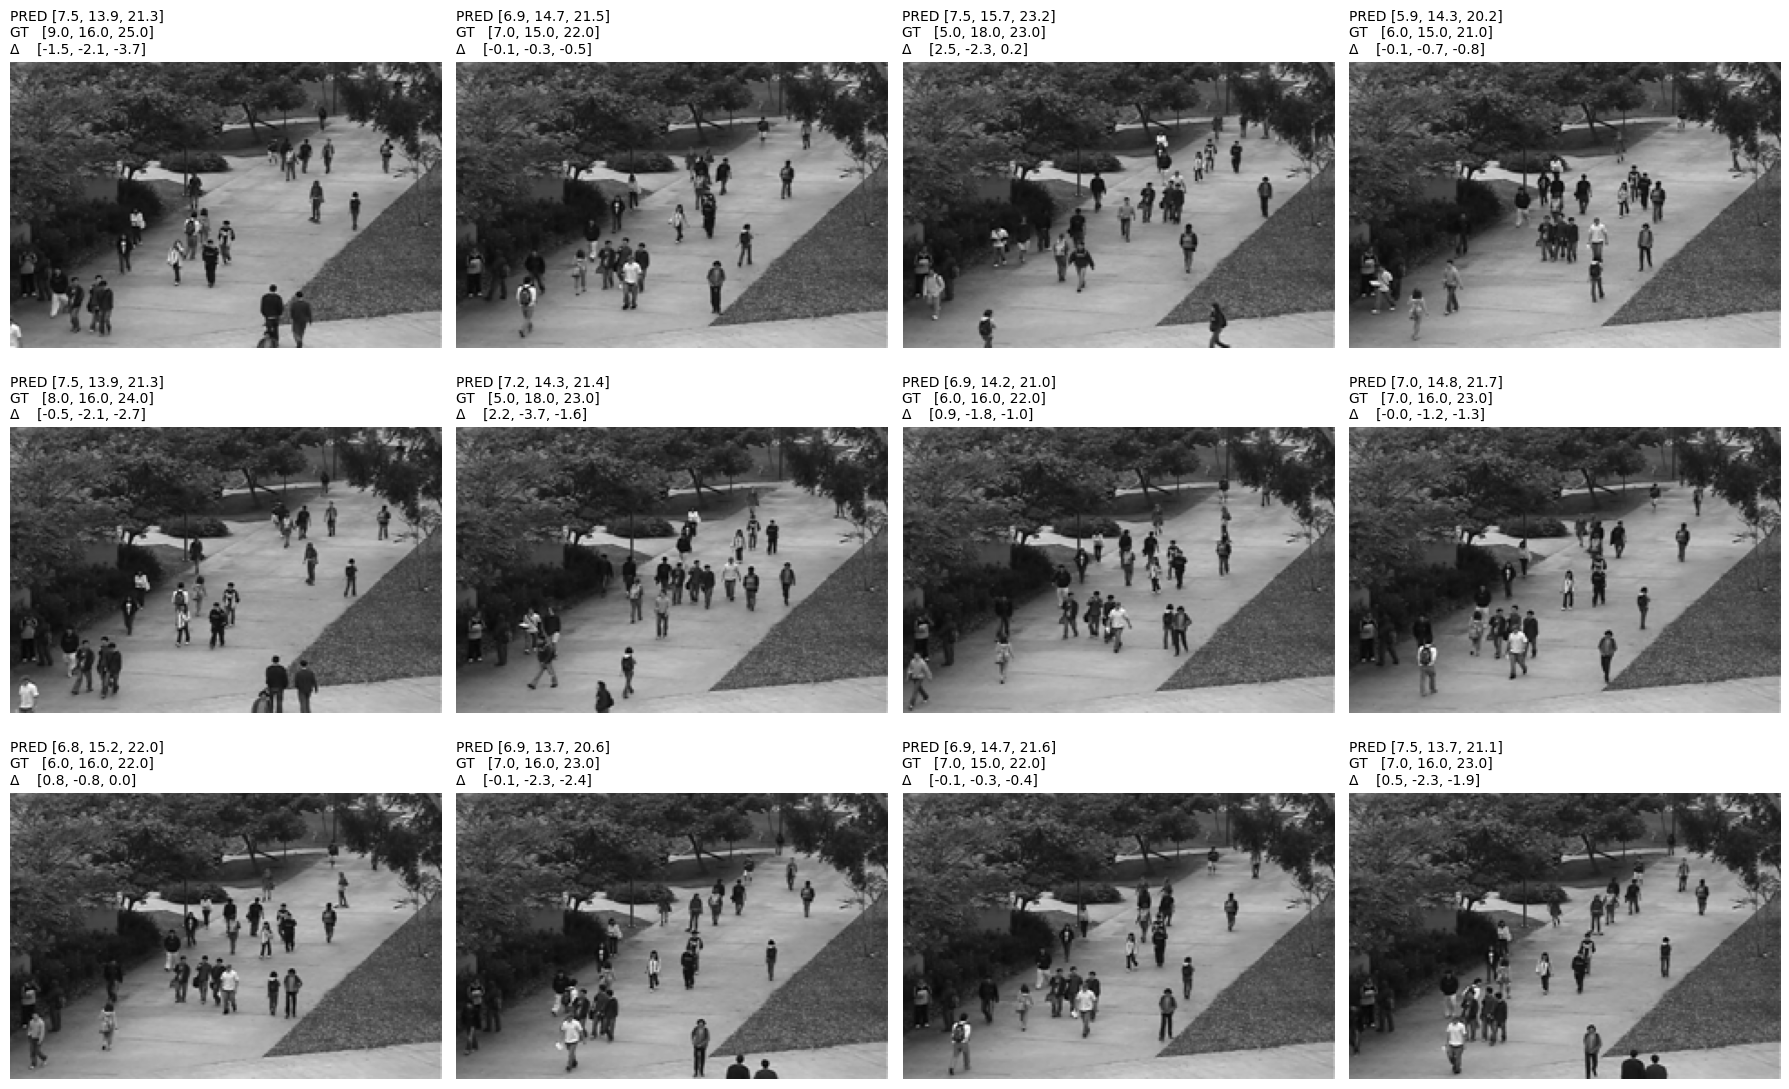

In [13]:
from tqdm.auto import tqdm

_ckpt_path = ckpt_path if 'ckpt_path' in globals() else 'model.pth'

if os.path.exists(_ckpt_path):
  try:
    # Load checkpoint
    ck = torch.load(_ckpt_path, map_location=device)
    model.load_state_dict(ck)
    print(f"[INFO] Loaded model state dict from checkpoint: {_ckpt_path}")

  except Exception as e:
    print(f"[ERROR] Error loading checkpoint {_ckpt_path}: {e}")
    print("[WARN] Evaluating current in-memory weights.")
else:
  print("[WARN] No checkpoint found; evaluating current in-memory weights.")

model.eval()
abs_sum = torch.zeros(3, dtype=torch.float64)
sqr_sum = torch.zeros(3, dtype=torch.float64)

# Image number to display after testing
num_show = 12
sampled = []
seen = 0

with torch.no_grad():
  test_bar = tqdm(test_loader, desc="Evaluating", leave=False)
  for batch_idx, (in_img, people_cnts) in enumerate(test_bar):
    in_img = in_img.to(device, non_blocking=True)
    people_cnts = people_cnts.to(device, non_blocking=True)
    pred_cnts = model(in_img)

    err = pred_cnts - people_cnts
    abs_sum += err.abs().sum(dim=0).double().cpu()
    sqr_sum += (err**2).sum(dim=0).double().cpu()

    # Reservoir sampling: keep a random 12 from the whole stream
    B = in_img.size(0)
    for i in range(B):
      if len(sampled) < num_show:
        sampled.append((
          in_img[i].detach().cpu(),
          people_cnts[i].detach().cpu(),
          pred_cnts[i].detach().cpu()
        ))
      else:
        j = random.randint(0, seen)
        if j < num_show:
          sampled[j] = (
            in_img[i].detach().cpu(),
            people_cnts[i].detach().cpu(),
            pred_cnts[i].detach().cpu()
          )
      seen += 1

    test_bar.set_postfix({
      'MAE[r, l, t]' : [f"{(abs_sum[i]/((batch_idx + 1) * people_cnts.size(0))):.4f}" for i in range(3)],
      'RMSE[r, l, t]': [f"{(sqr_sum[i]/((batch_idx + 1) * people_cnts.size(0))).sqrt().item():.4f}" for i in range(3)],
    })

# Calculate final metrics
test_mae = (abs_sum / len(test_ds)).tolist()
test_rmse = torch.sqrt(sqr_sum / len(test_ds)).tolist()

# Print results
print(f"[TEST]  MAE[r,l,t] = [{test_mae[0]:.4f}, {test_mae[1]:.4f}, {test_mae[2]:.4f}] | "
      f"Avg  MAE = {(sum(test_mae)/3):.4f}")
print(f"[TEST] RMSE[r,l,t] = [{test_rmse[0]:.4f}, {test_rmse[1]:.4f}, {test_rmse[2]:.4f}] | "
      f"Avg RMSE = {(sum(test_rmse)/3):.4f}")

# Plotting
n = len(sampled)
cols = min(4, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.5*cols, 3.8*rows))
if rows == 1 and cols == 1:
  axes = np.array([[axes]])
elif rows == 1:
  axes = np.array([axes])

for idx, (img, gt, pred) in enumerate(sampled):
  ax = axes[idx // cols, idx % cols]
  img = (img * 0.5 + 0.5).clamp(0, 1).squeeze(0).numpy()
  ax.imshow(img, cmap='gray')
  ax.axis('off')
  gt_np = gt.numpy(); pr_np = pred.numpy(); delta = pr_np - gt_np
  ax.set_title(
    f"PRED [{pr_np[0]:.1f}, {pr_np[1]:.1f}, {pr_np[2]:.1f}]\n"
    f"GT   [{gt_np[0]:.1f}, {gt_np[1]:.1f}, {gt_np[2]:.1f}]\n"
    f"Δ    [{delta[0]:.1f}, {delta[1]:.1f}, {delta[2]:.1f}]",
    fontsize=10, loc='left'
  )

for j in range(n, rows*cols):
  axes[j // cols, j % cols].axis('off')

plt.tight_layout()
plt.show()